In [1]:
import polars as pl 
from pathlib import Path
# Setting the files path 

# Folers
en_folder  = Path("../dataset/en")
fr_folder  = Path("../dataset/fr")
ml_folder  = Path("../dataset/multilinguinal")
sp_folder = Path("../dataset/stopwords")

# English files 
en_train_file  = en_folder / "en_train.parquet"
en_test_file  = en_folder / "en_test.parquet"
en_sp = sp_folder  / "stopwords-en.txt"
# French files 
fr_train_file  = fr_folder / "fr_train.parquet"
fr_test_file  = fr_folder / "fr_test.parquet"
fr_sp= sp_folder  / "stopwords-fr.txt"

In [2]:
# reading the english df 
en_train_df = pl.scan_parquet(en_train_file)
# reading the french df
fr_train_df  = pl.scan_parquet(fr_train_file)

In [3]:
# Inspecting the dataset schema 
print("English schema : ", en_train_df.collect_schema())
print("French schema : ", fr_train_df.collect_schema())

English schema :  Schema({'text_clean': String, 'label': Int64})
French schema :  Schema({'text': String, 'label': Int32})


In [4]:
def clean_and_filter(df,label,txt_col,language):
    """
    - This filter selet samples based on their labels
    - Removes null rows
    - Replace extra white spaces with normal ones
    - Returns unique samples base don text 

    """
    filter = lambda label,text_col : (pl.col("label") == label) & pl.col(text_col).is_not_null() & (pl.col(text_col) != "")
    return df \
               .filter(filter(label,txt_col))\
               .with_columns(
                   pl.col(txt_col)
                   .str.strip_chars()
                   .str.replace_all(r"\s+", " ")
                   .alias(txt_col),
                   pl.lit(language).alias("lang")
                ).unique(subset=[txt_col])

In [5]:
ai_en  = clean_and_filter(en_train_df,1,"text_clean","en").rename({"text_clean":"text"})
human_en  = clean_and_filter(en_train_df,0,"text_clean","en").rename({"text_clean":"text"}) 
ai_fr = clean_and_filter(fr_train_df,1,"text","fr")
human_fr = clean_and_filter(fr_train_df,0,"text","fr")

In [6]:
print(ai_en.collect_schema())
print(human_en.collect_schema())
print(ai_fr.collect_schema())
print(human_fr.collect_schema())

Schema({'text': String, 'label': Int64, 'lang': String})
Schema({'text': String, 'label': Int64, 'lang': String})
Schema({'text': String, 'label': Int32, 'lang': String})
Schema({'text': String, 'label': Int32, 'lang': String})


In [9]:
def sample_df(df,n_samples,seed):
    return df.collect()\
            .sample(n=n_samples,seed=seed,shuffle=True)

In [10]:
ai_en= sample_df(ai_en,110_000,42) 
human_en= sample_df(human_en,140_000,42) 
ai_fr= sample_df(ai_fr,110_000,42) 
human_fr= sample_df(human_fr,140_000,42) 

In [11]:
val_ai_en = ai_en[:10_000]
ai_en = ai_en[10_000:]
val_human_en = human_en[:40_000]
human_en = human_en[40_000:]
val_ai_fr = ai_fr[:10_000]
ai_fr = ai_fr[10_000:]
val_human_fr = human_fr[:40_000]
human_fr = human_fr[40_000:]

In [12]:
# Adding some OCE and keyboard noise to the data 
# Reading stopwords for each language 
with en_sp.open(mode="r",encoding="utf-8") as f:
    sp_en = f.read().splitlines()
with fr_sp.open(mode="r", encoding="utf-8") as f:
    sp_fr = f.read().splitlines()

In [13]:
from nlpaug.augmenter.char.ocr import OcrAug

ai_en_ocr_augmenter = OcrAug(
    aug_char_p=0.12,
    aug_char_min=1,
    aug_char_max=2,
    aug_word_p=0.03,
    stopwords=sp_en
)
human_en_ocr_augmenter = OcrAug(
    aug_char_p=0.25,
    aug_char_min=1,
    aug_char_max=2,
    aug_word_p=0.05,
    stopwords=sp_en
)

ai_fr_ocr_augmenter = OcrAug(
    aug_char_p=0.12,
    aug_char_min=1,
    aug_char_max=2,
    aug_word_p=0.03,
    stopwords=sp_fr
)

human_fr_ocr_augmenter = OcrAug(
    aug_char_p=0.25,
    aug_char_min=1,
    aug_char_max=2,
    aug_word_p=0.05,
    stopwords=sp_fr
)

In [14]:
from nlpaug.augmenter.char.keyboard import KeyboardAug

ai_en_keyboard_augmenter = KeyboardAug(
    aug_char_p=0.10,
    aug_char_min=1,
    aug_char_max=2,
    aug_word_p=0.02,
    stopwords=sp_en
)

human_en_keyboard_augmenter = KeyboardAug(
    aug_char_p=0.20,
    aug_char_min=1,
    aug_char_max=2,
    aug_word_p=0.05,
    stopwords=sp_en
)

ai_fr_keyboard_augmenter = KeyboardAug(
    aug_char_p=0.10,
    aug_char_min=1,
    aug_char_max=2,
    aug_word_p=0.02,
    stopwords=sp_fr,
    lang="fr"
)
human_fr_keyboard_augmenter = KeyboardAug(
    aug_char_p=0.20,
    aug_char_min=1,
    aug_char_max=2,
    aug_word_p=0.05,
    stopwords=sp_fr,
    lang="fr"
)

In [15]:
# Sample from to augmente the data 
augment_ai_en_df = ai_en.sample(n=25_000,seed=25,shuffle=True)
ocr_ai_en = augment_ai_en_df[:22_500]
key_ai_en = augment_ai_en_df[22_500:]

In [16]:
augment_ai_fr_df = ai_fr.sample(n=25_000,seed=25,shuffle=True)
ocr_ai_fr = augment_ai_fr_df[:22_500]
key_ai_fr = augment_ai_fr_df[22_500:]

In [17]:
# Sample from to augmente the data 
augment_human_en_df = human_en.sample(n=25_000,seed=25,shuffle=True)
ocr_human_en = augment_human_en_df[22_500:]
key_human_en = augment_human_en_df[:22_500]

In [18]:
# Sample from to augmente the data 
augment_human_fr_df = human_fr.sample(n=25_000,seed=25,shuffle=True)
ocr_human_fr = augment_human_fr_df[22_500:]
key_human_fr = augment_human_fr_df[:22_500]

In [19]:
def agumente_text(text,augmenter):
    return " ".join(augmenter.augment(text))

In [20]:
ocr_ai_en = ocr_ai_en.with_columns(
    pl.col("text").map_elements(lambda x : agumente_text(x,ai_en_ocr_augmenter),return_dtype=pl.Utf8)
)
ocr_ai_fr = ocr_ai_fr.with_columns(
    pl.col("text").map_elements(lambda x : agumente_text(x,ai_fr_ocr_augmenter),return_dtype=pl.Utf8)
)
ocr_human_en = ocr_human_en.with_columns(
    pl.col("text").map_elements(lambda x : agumente_text(x,human_en_ocr_augmenter),return_dtype=pl.Utf8)
)
ocr_human_fr = ocr_human_fr.with_columns(
    pl.col("text").map_elements(lambda x : agumente_text(x,human_fr_ocr_augmenter),return_dtype=pl.Utf8)
)

In [21]:
key_ai_en = key_ai_en.with_columns(
    pl.col("text").map_elements(lambda x : agumente_text(x,ai_en_keyboard_augmenter),return_dtype=pl.Utf8)
)
key_ai_fr = key_ai_fr.with_columns(
    pl.col("text").map_elements(lambda x : agumente_text(x,ai_fr_keyboard_augmenter),return_dtype=pl.Utf8)
)
key_human_en = key_human_en.with_columns(
    pl.col("text").map_elements(lambda x : agumente_text(x,human_en_keyboard_augmenter),return_dtype=pl.Utf8)
)
key_human_fr = key_human_fr.with_columns(
    pl.col("text").map_elements(lambda x : agumente_text(x,human_fr_keyboard_augmenter),return_dtype=pl.Utf8)
)

In [22]:
key_ai_fr = key_ai_fr.with_columns(pl.lit(1).alias("is_augmented"))
key_ai_en = key_ai_en.with_columns(pl.lit(1).alias("is_augmented"))
key_human_fr = key_human_fr.with_columns(pl.lit(1).alias("is_augmented"))
key_human_en = key_human_en.with_columns(pl.lit(1).alias("is_augmented"))
ocr_ai_fr = ocr_ai_fr.with_columns(pl.lit(1).alias("is_augmented"))
ocr_ai_en = ocr_ai_en.with_columns(pl.lit(1).alias("is_augmented"))
ocr_human_fr = ocr_human_fr.with_columns(pl.lit(1).alias("is_augmented"))
ocr_human_en =  ocr_human_en.with_columns(pl.lit(1).alias("is_augmented"))

In [23]:
ai_en = ai_en.with_columns(pl.lit(0).alias("is_augmented"))
ai_fr = ai_fr.with_columns(pl.lit(0).alias("is_augmented"))
human_en = human_en.with_columns(pl.lit(0).alias("is_augmented"))
human_fr = human_fr.with_columns(pl.lit(0).alias("is_augmented"))

In [24]:
def fix_dtype(df):
    return df.with_columns(
        pl.col("label").cast(pl.Int64)
    )

In [25]:
train_df = pl.concat([
    fix_dtype(key_ai_fr),
    fix_dtype(key_ai_en),
    fix_dtype(key_human_en),
    fix_dtype(key_human_fr),
    fix_dtype(ocr_ai_en),
    fix_dtype(ocr_ai_fr),
    fix_dtype(ocr_human_en),
    fix_dtype(ai_en),
    fix_dtype(ai_fr),
    fix_dtype(human_en),
    fix_dtype(human_fr),
])

In [26]:
train_df.schema

Schema([('text', String),
        ('label', Int64),
        ('lang', String),
        ('is_augmented', Int32)])

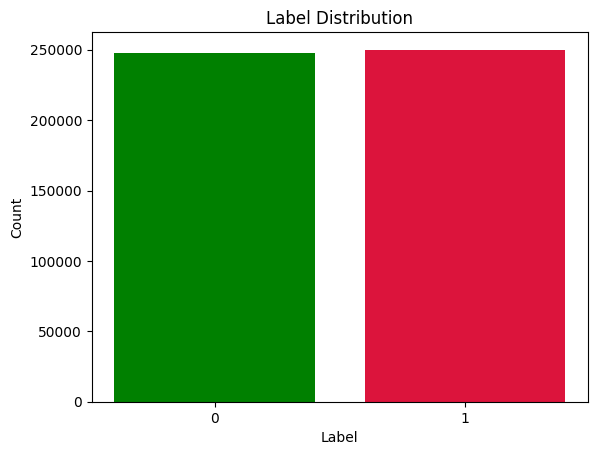

In [27]:
import matplotlib.pyplot as plt 
label_counts = train_df["label"].value_counts().sort("label")
x = label_counts["label"].to_list()
plt.bar(x=x,height=label_counts["count"].to_list(),color=["green","crimson"])
plt.xticks(x) 
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Label Distribution")
plt.show()

In [28]:
import numpy as np 
ai = train_df.filter(pl.col("label") == 1)
human = train_df.filter(pl.col("label") == 0)

ai_wc = ai.select(
    pl.col("text").str.split(" ").list.len().map_elements(lambda x : np.log10(x)).alias("wc")
)["wc"].to_list()

human_wc = human.select(
    pl.col("text").str.split(" ").list.len().map_elements(lambda x : np.log10(x)).alias("wc")
)["wc"].to_list()

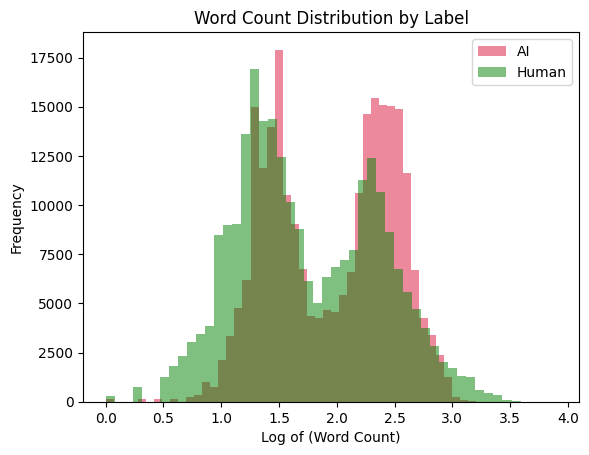

In [29]:
plt.hist(ai_wc, bins=50, alpha=0.5, label="AI", color="crimson")
plt.hist(human_wc, bins=50, alpha=0.5, label="Human", color="green")

plt.xlabel("Log of (Word Count)")
plt.ylabel("Frequency")
plt.title("Word Count Distribution by Label")
plt.legend()

plt.show()

In [ ]:
# SHUFFLE the dataset
train_df = train_df.sample(
    fraction=1.0,
    shuffle=True,
    seed=42
)
train_df.write_parquet(
    ml_folder / "ml_train.parquet",
    compression="snappy"
)

In [31]:
val_df = pl.concat(
    [
        fix_dtype(val_ai_en),
        fix_dtype(val_ai_fr),
        fix_dtype(val_human_en),
        fix_dtype(val_human_fr),
    ]
)

In [32]:
val_df.write_parquet(
    ml_folder / "ml_val.parquet",
    compression="snappy"
)

In [125]:
# reading the test set 
test_en  = pl.scan_parquet(en_test_file)
test_fr = pl.scan_parquet(fr_test_file)

In [126]:
print("English : ",test_en.collect_schema())
print("French: ",test_fr.collect_schema())

English :  Schema({'text_clean': String, 'label': Int64})
French:  Schema({'text': String, 'label': Int32})


In [127]:
test_en = fix_dtype(
    test_en.rename({"text_clean": "text"})
).with_columns(
    pl.lit("en").alias("lang")
)

test_fr = fix_dtype(
    test_fr
).with_columns(
    pl.lit("fr").alias("lang")
)

In [128]:
test_df  = pl.concat([
    test_en,
    test_fr
])

In [134]:
test_df = test_df.collect()

In [136]:
language_counts  = test_df["lang"].value_counts().sort("lang")

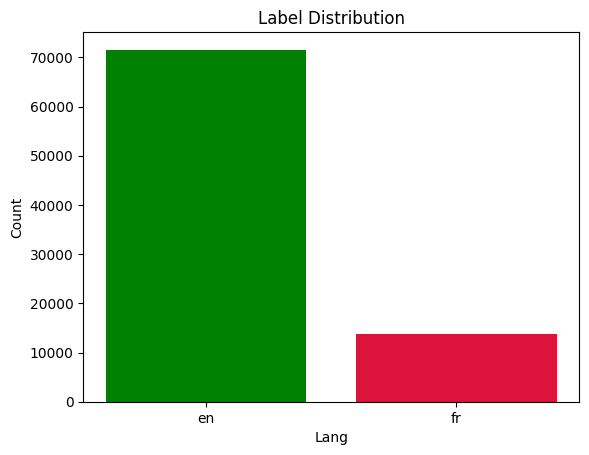

In [137]:

x = language_counts["lang"].to_list()
plt.bar(x=x,height=language_counts["count"].to_list(),color=["green","crimson"])
plt.xticks(x) 
plt.xlabel("Lang")
plt.ylabel("Count")
plt.title("Label Distribution")
plt.show()

In [138]:
language_counts

lang,count
str,u32
"""en""",71541
"""fr""",13783


In [ ]:
test_df = test_df.sample(
    fraction=1.0,
    shuffle=True,
    seed=42
)
test_df.write_parquet(
    ml_folder / "ml_test.parquet",
    compression="snappy"
)

In [33]:
%reset -f